# **Classify the Emails into Spam or Not.**

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Reading the Data

In [2]:
df = pd.read_csv('spam_or_not_spam.csv')
df

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


# Understanding the Data

In [3]:
df.dtypes

email    object
label     int64
dtype: object

In [4]:
df.shape

(3000, 2)

In [5]:
df.size

6000

In [6]:
df.columns

Index(['email', 'label'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2999 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [8]:
df.describe()

,label
count,3000.000000
mean,0.166667
std,0.372740
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [9]:
df.corr(numeric_only=True)

,label
label,1.0


In [10]:
df.nunique()

email    2872
label       2
dtype: int64

In [11]:
df.isnull().any()

email     True
label    False
dtype: bool

# Data Visualization

<Axes: >

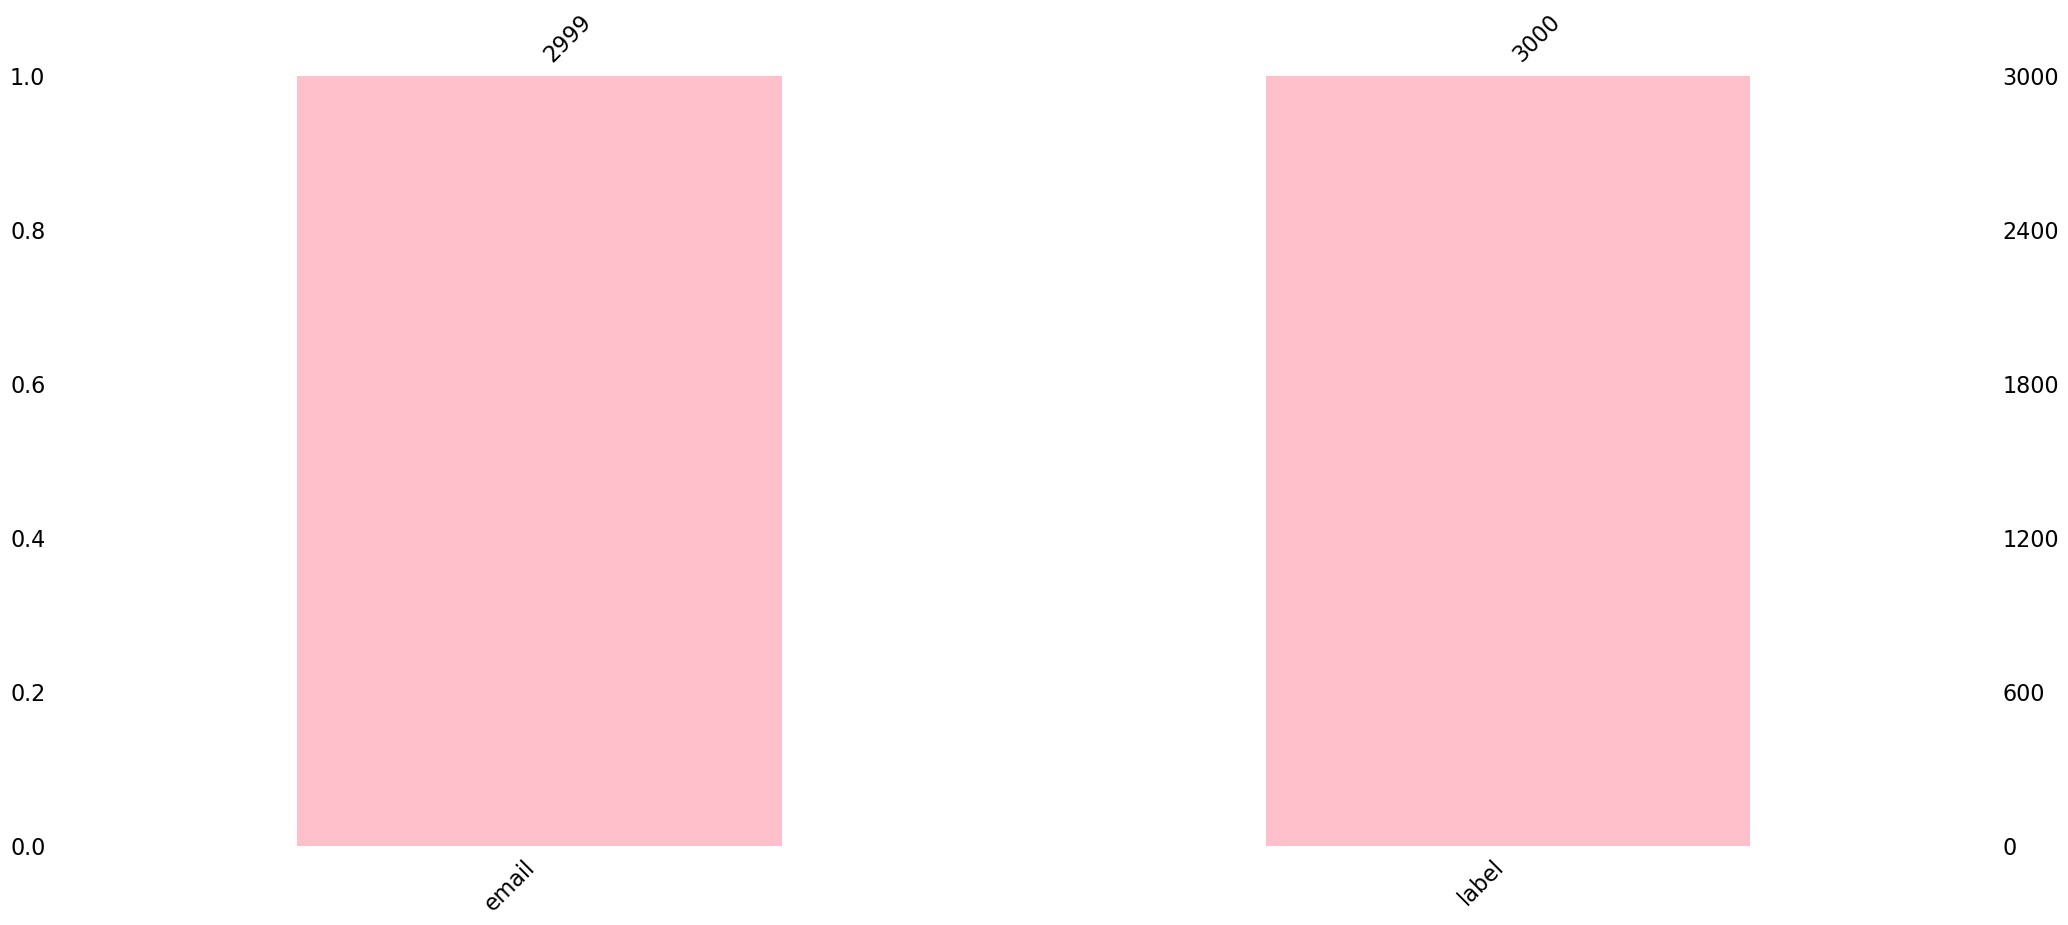

In [12]:
import missingno as no
no.bar(df, color='pink')

<Axes: >

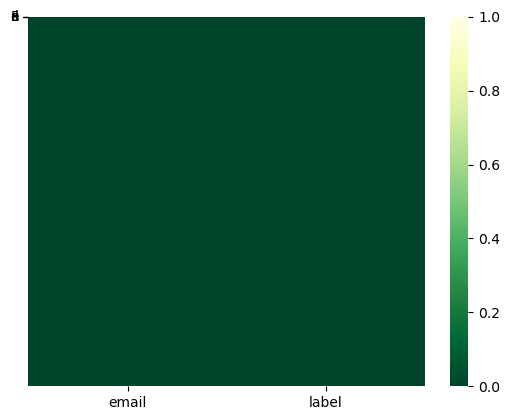

In [13]:
sns.heatmap(df.isnull(), yticklabels='False', cmap='YlGn_r')

In [14]:
df = df.dropna()

<Axes: ylabel='count'>

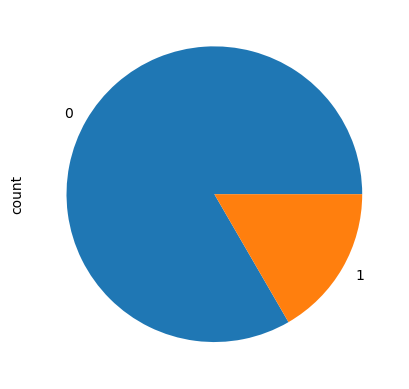

In [15]:
df.label.value_counts().plot(kind ='pie')

/var/folders/sc/r00qn7g96s95hmmhkr9v8x080000gn/T/ipykernel_4333/1200036629.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df.label, palette='gist_rainbow')


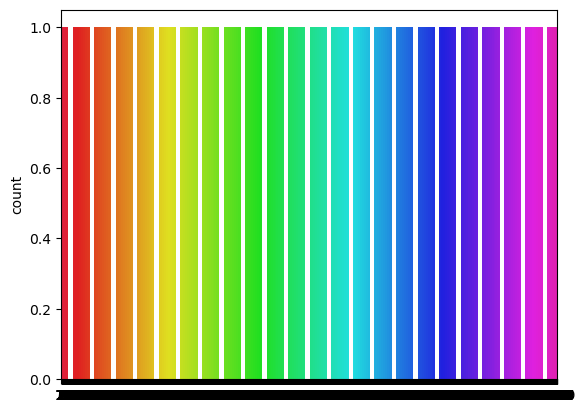

In [16]:
sns.countplot(df.label, palette='gist_rainbow')
plt.show()

/var/folders/sc/r00qn7g96s95hmmhkr9v8x080000gn/T/ipykernel_4333/2209339926.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['label'], color='y')


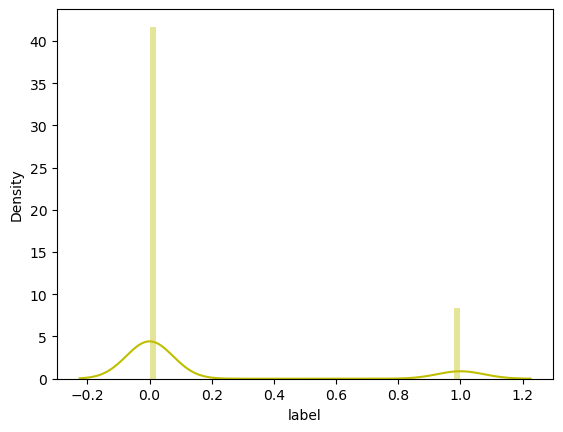

In [17]:
sns.distplot(df['label'], color='y')
plt.show()

# Splitting the Data into Dependent and Indpendent variables

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

In [19]:
x = df['email']
X = tfidf.fit_transform(x)
y = df['label']

# Training and Testing the Data

In [20]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=10)

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

# Multiomial Naive Bayes Classifier

In [22]:
mnb = MultinomialNB()
mnb.fit(Xtrain, ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Prediction

In [23]:
ypred_train = mnb.predict(Xtrain)
ypred_test = mnb.predict(Xtest)

## Confusion Matrix

In [24]:
cm = confusion_matrix(ytest, ypred_test)
cm

array([[628,   0],
       [ 83,  39]])

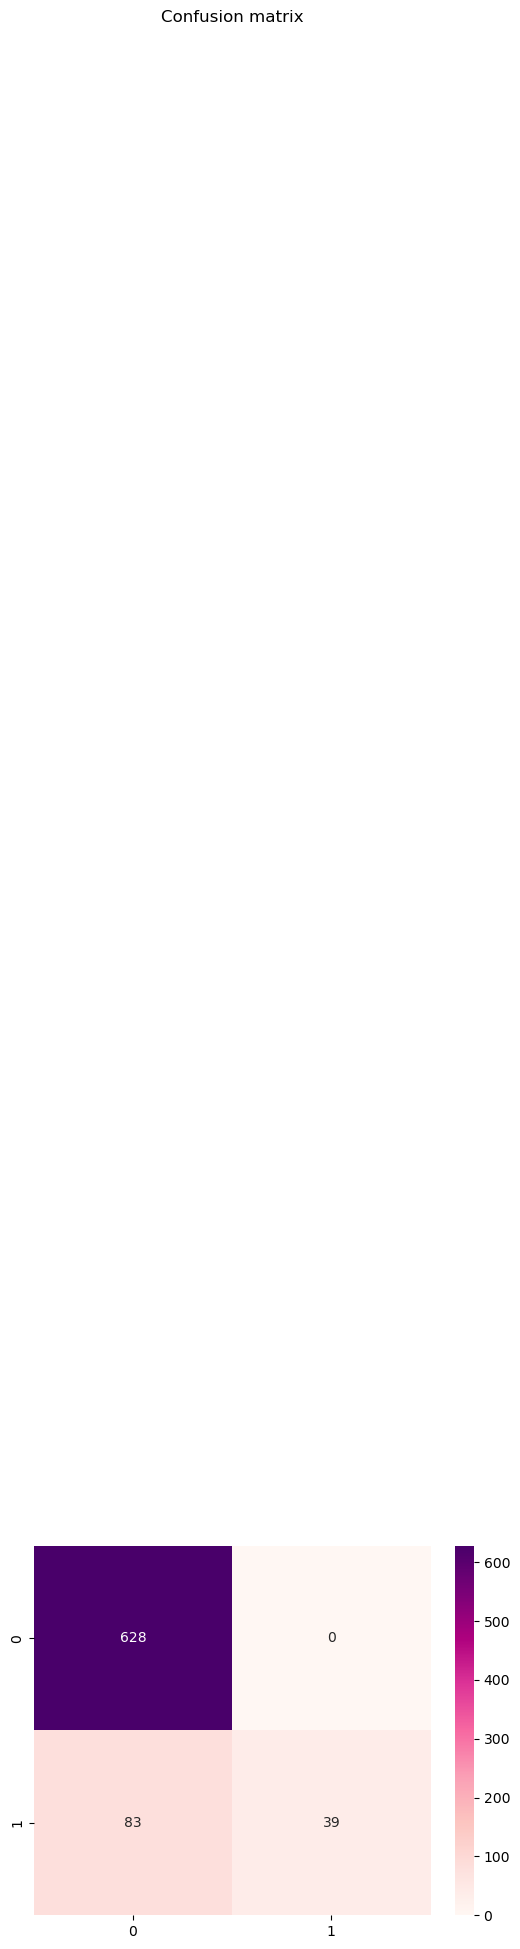

In [25]:
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="RdPu" ,fmt='g')
plt.title('Confusion matrix', y=5.1)
plt.show()

## Accuracy

In [26]:
print("Accuracy of training data:", accuracy_score(ytrain, ypred_train)*100)
ac2 = accuracy_score(ytest, ypred_test)*100
print("Accuracy of testing data:", ac2)

Accuracy of training data: 90.7514450867052
Accuracy of testing data: 88.93333333333334


# Decission Tree

In [27]:
dt = DecisionTreeClassifier()
dt.fit(Xtrain, ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction

In [28]:
ypred_train = dt.predict(Xtrain)
ypred_test = dt.predict(Xtest)

## Confusion Matrix

In [29]:
cm = np.array(confusion_matrix(ypred_test, ytest))
cm

array([[597,  12],
       [ 31, 110]])

<Axes: >

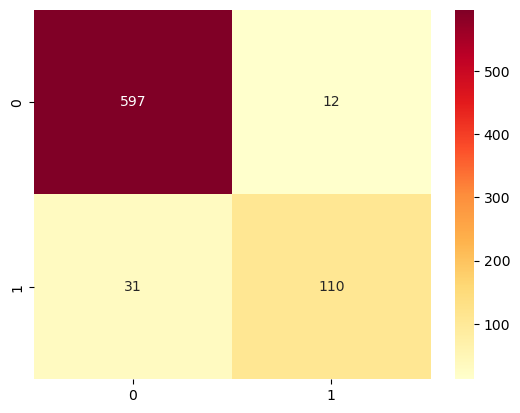

In [30]:
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlOrRd" ,fmt='g')


## Accuracy

In [31]:
print("Accuracy of training data:", accuracy_score(ytrain, ypred_train)*100)
ac1 = accuracy_score(ytest, ypred_test)*100
print("Accuracy of testing data:", ac1)

Accuracy of training data: 100.0
Accuracy of testing data: 94.26666666666667


[Text(0.5909090909090909, 0.875, 'x[13291] <= 0.008\ngini = 0.279\nsamples = 2249\nvalue = [1872, 377]'),
 Text(0.36363636363636365, 0.625, 'x[24142] <= 0.03\ngini = 0.188\nsamples = 2090\nvalue = [1871, 219]'),
 Text(0.4772727272727273, 0.75, 'True  '),
 Text(0.18181818181818182, 0.375, 'x[5071] <= 0.032\ngini = 0.142\nsamples = 1996\nvalue = [1843, 153]'),
 Text(0.09090909090909091, 0.125, 'gini = 0.106\nsamples = 1934\nvalue = [1825, 109]'),
 Text(0.2727272727272727, 0.125, 'gini = 0.412\nsamples = 62\nvalue = [18, 44]'),
 Text(0.5454545454545454, 0.375, 'x[13907] <= 0.009\ngini = 0.418\nsamples = 94\nvalue = [28, 66]'),
 Text(0.45454545454545453, 0.125, 'gini = 0.498\nsamples = 47\nvalue = [25, 22]'),
 Text(0.6363636363636364, 0.125, 'gini = 0.12\nsamples = 47\nvalue = [3.0, 44.0]'),
 Text(0.8181818181818182, 0.625, 'x[30745] <= 0.033\ngini = 0.012\nsamples = 159\nvalue = [1, 158]'),
 Text(0.7045454545454546, 0.75, '  False'),
 Text(0.7272727272727273, 0.375, 'gini = 0.0\nsamples =

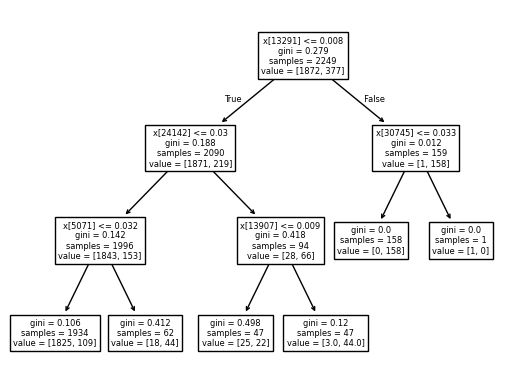

In [32]:
from sklearn import tree
clf_tree = tree.DecisionTreeClassifier(max_depth=3)
clf_tree.fit(Xtrain, ytrain)
tree.plot_tree(clf_tree)